# 3. 행렬곱으로 이해하는 신경망

## 1. 순전파(Foward Propagation)

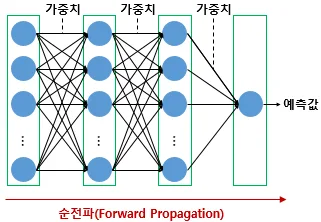

- 활성화 함수, 은닉층의 수, 각 은닉층의 뉴런 수 등 딥 러닝 모델을 설계하고나면 입력값은 입력층, 은닉층을 지나면서 각 층에서의 가중치와 함께 연산되며 출력층으로 향한다.

- 출력층에서 모든 연산을 마친 예측값이 나오게 되며, 이와 같이 입력층에서 출력층 방향으로 예측값의 연산이 진행되는 과정을 순전파라고 한다.

## 2. 행렬곱으로 순전파 이해하기

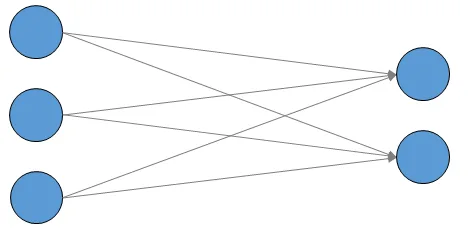

- 위와 같은 인공 신경망이 있다고 해봅시다. 입력의 차원이 3, 출력의 차원이 2인 위 인공 신경망을 구현해본다면 다음과 같습니다.

In [2]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(3,)),
    Dense(2, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

- 소프트맥스 회귀를 한다고 가정하고 활성화 함수는 소프트맥스 함수를 임의로 기재하였습니다. 인공 신경망이란 표현이 아직 어색한다면 앞에서 배운 소프트맥스 회귀 모델을 만들었다고 생각해도 되겠습니다. 

- 소프트맥스 회귀는 출력 벡터의 차원을 2로 두면 이진 분류를 수행하는 모델이 되며, 로지스틱 회귀가 아닌 소프트맥스 회귀로도 이진 분류는 수행 가능합니다.

- 케라스에서는 .summary()를 사용하면 해당 모델에 존재하는 모든 매개변수(가중치 w 
와 편향 b의 개수)를 확인할 수 있습니다.

- 매개변수의 수가 8개라고 나옵니다. 위 신경망에서 학습가능한 매개변수 인w
와 b의 개수가 총 합해서 8개라는 의미입니다. 실제로 그런지 위 신경망을 행렬의 곱셈 관점에서 이해해봅시다.

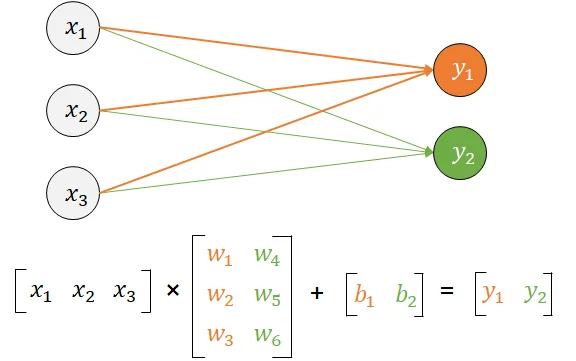

## 3. 행렬곱으로 병렬 연산 이해하기

- 인공 신경망을 행렬곱으로 구현할 때의 흥미로운 점은 행렬곱을 사용하면 병렬 연산도 가능하다는 점입니다. 위의 예시에서는 데이터 중 1개의 샘플만을 처리한다고 가정했습니다. 

- 이번에는 인공 신경망이 4개의 샘플을 동시에 처리해본다고 가정해봅시다. 4개의 샘플을 하나의 행렬 
로 정의하고 인공 신경망의 순전파를 행렬곱으로 표현하면 다음과 같습니다.

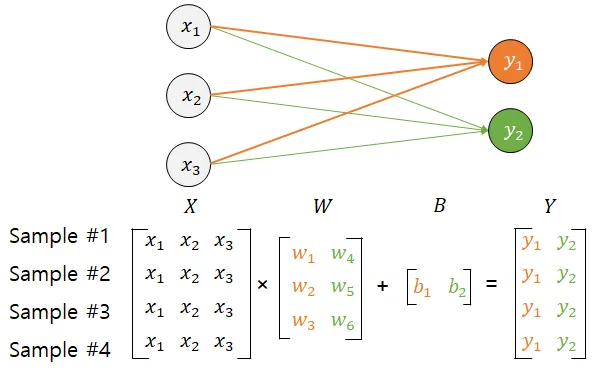

- 여기서 혼동하지 말아야 할 것은 인공 신경망의 4개의 샘플을 동시에 처리하고 있지만, 여기서 학습가능한 매개변수의 수는 여전히 8개라는 점입니다. 이렇게 인공 신경망이 다수의 샘플을 동시에 처리하는 것을 우리는 '배치 연산'이라고 부릅니다.

- 난이도를 올려서 중간에 층을 더 추가해봅시다.

## 4. 행렬곱으로 다층 퍼셉트론의 순전파 이해하기

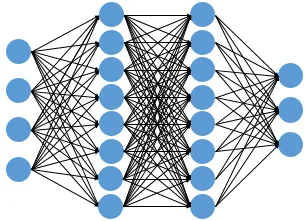

위와 같은 인공 신경망이 있으며, 주어진 인공 신경망을 케라스로 구현해본다면 아래와 같이 구현할 수 있습니다.

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(4,)),                 # 특성 4개
    Dense(8, activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")     # 클래스 3개
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139 (556.00 B)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

## 버전 확인용 👇

In [5]:
import sys
import platform

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Architecture:", platform.architecture())
print("Machine:", platform.machine())

Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Executable: c:\Users\최재화\AppData\Local\Python\pythoncore-3.14-64\python.exe
Architecture: ('64bit', 'WindowsPE')
Machine: AMD64


In [6]:
%pip config list

Note: you may need to restart the kernel to use updated packages.


In [9]:
import sys
import platform

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Architecture:", platform.architecture())
print("Machine:", platform.machine())

%pip --version
%pip config list

Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Executable: c:\Users\최재화\AppData\Local\Python\pythoncore-3.14-64\python.exe
Architecture: ('64bit', 'WindowsPE')
Machine: AMD64
pip 26.2.1 from c:\Users\최재화\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip (python 3.14)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 2.4 MB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.6 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.1.2
    Uninstalling pip-26.1.2:
      Successfully uninstalled pip-26.1.2
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import sys

print(sys.executable)

c:\Users\최재화\AppData\Local\Programs\Python\Python312\python.exe


In [7]:
%pip install --upgrade pip

  Using cached pip-26.2.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.2.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.3.0-cp312-cp312-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.83.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached k

In [1]:
import sys
import tensorflow as tf

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)
print("장치:", tf.config.list_physical_devices())

Python: c:\Users\최재화\AppData\Local\Programs\Python\Python312\python.exe
TensorFlow: 2.21.0
장치: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
